### ML Lab 6
#### Name: Madhavi katekhaye
#### Section-Batch: B-B2
#### Roll No.:22

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [6]:
df=pd.read_csv("seeds.csv")

In [7]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)",Unnamed: 8,Unnamed: 9
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,NaN,NaN
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,NaN,NaN
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,NaN,NaN
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,NaN,NaN
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,NaN,NaN


In [8]:
df.tail()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)",Unnamed: 8,Unnamed: 9
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3,NaN,NaN
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3,NaN,NaN
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3,NaN,NaN
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3,NaN,NaN
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3,NaN,NaN


In [9]:
df.shape

(210, 10)

In [10]:
df.columns

Index(['Area', 'Perimeter', 'Compactness', 'Length of kernel',
       'Width of kernel', 'Asymmetry coefficient', 'Length of kernel groove',
       'Class (1, 2, 3)', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length of kernel         210 non-null    float64
 4   Width of kernel          210 non-null    float64
 5   Asymmetry coefficient    210 non-null    float64
 6   Length of kernel groove  210 non-null    float64
 7   Class (1, 2, 3)          210 non-null    int64  
 8   Unnamed: 8               2 non-null      str    
 9   Unnamed: 9               1 non-null      str    
dtypes: float64(7), int64(1), str(2)
memory usage: 16.5 KB


In [12]:
df.isnull().sum()

Area                         0
Perimeter                    0
Compactness                  0
Length of kernel             0
Width of kernel              0
Asymmetry coefficient        0
Length of kernel groove      0
Class (1, 2, 3)              0
Unnamed: 8                 208
Unnamed: 9                 209
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print(df["Class (1, 2, 3)"].value_counts().sort_index())

Class (1, 2, 3)
1    70
2    70
3    70
Name: count, dtype: int64


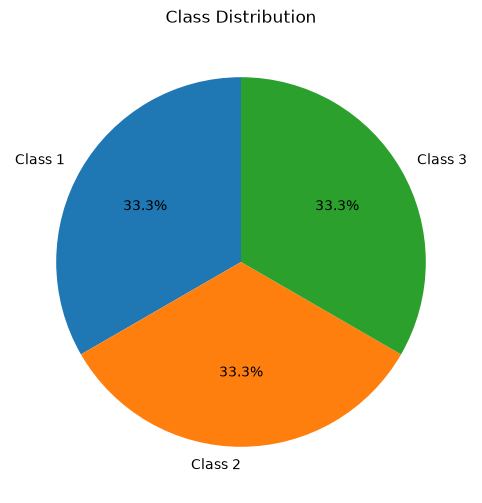

In [15]:
class_counts = df["Class (1, 2, 3)"].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(class_counts,labels=["Class 1","Class 2","Class 3"],autopct="%1.1f%%",startangle=90)
plt.title("Class Distribution")
plt.show()

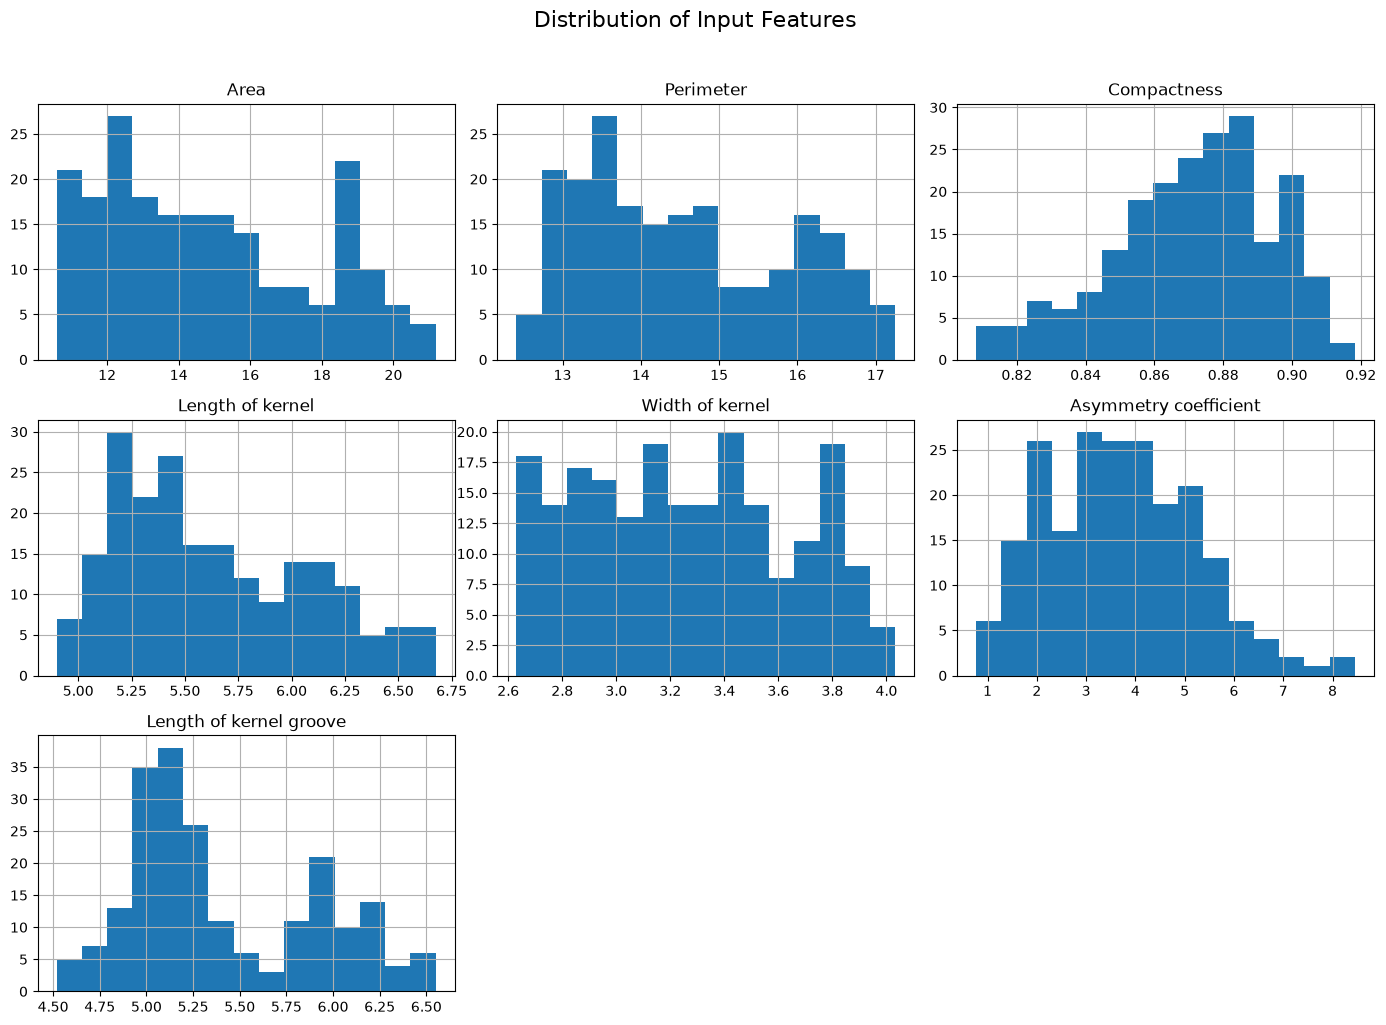

In [16]:
import matplotlib.pyplot as plt

df.drop("Class (1, 2, 3)", axis=1).hist(figsize=(14, 10), bins=15)
plt.suptitle("Distribution of Input Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


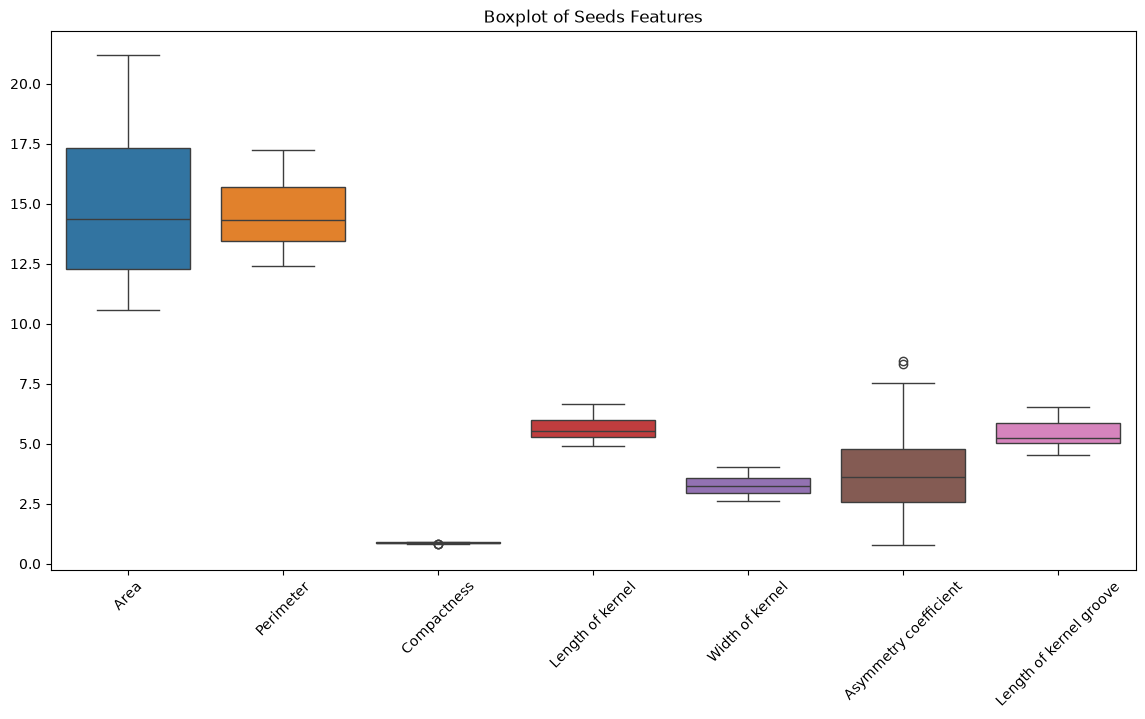

In [17]:
plt.figure(figsize=(14,7))

sns.boxplot(data=df.drop("Class (1, 2, 3)",axis=1))
plt.title("Boxplot of Seeds Features")
plt.xticks(rotation=45)
plt.show()

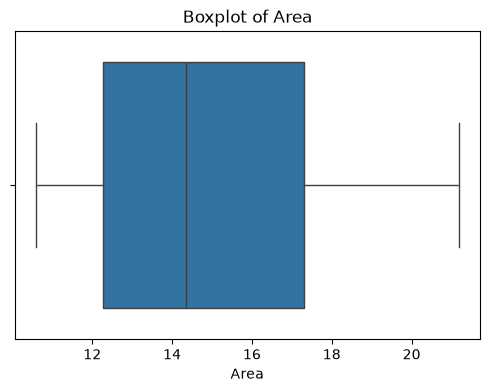

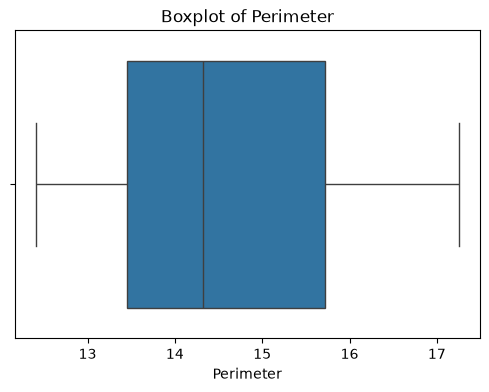

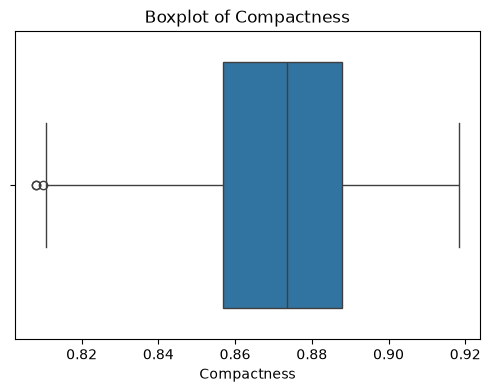

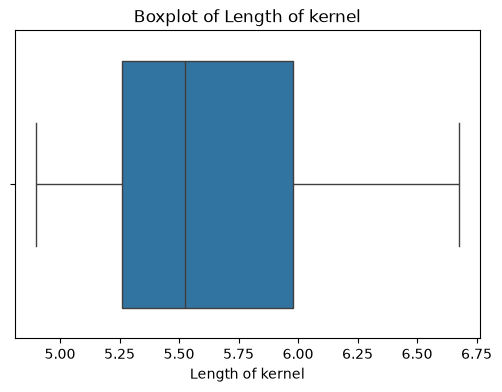

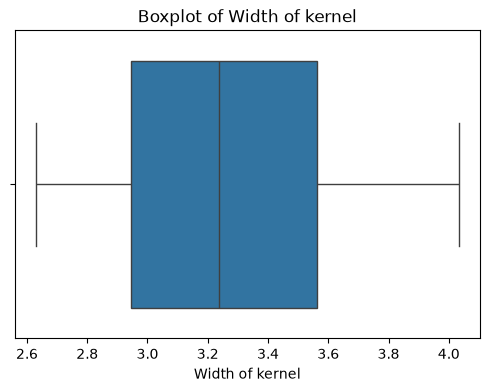

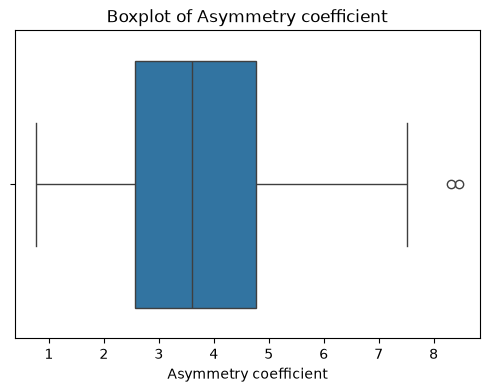

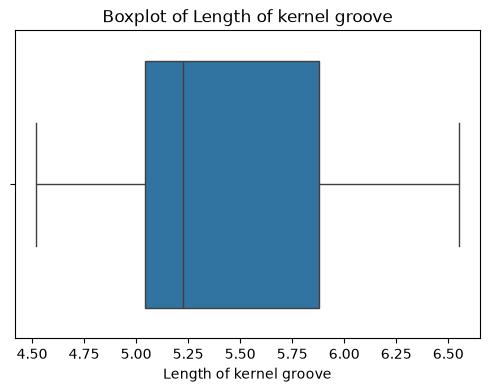

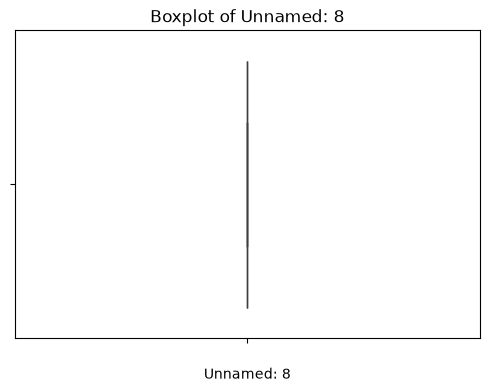

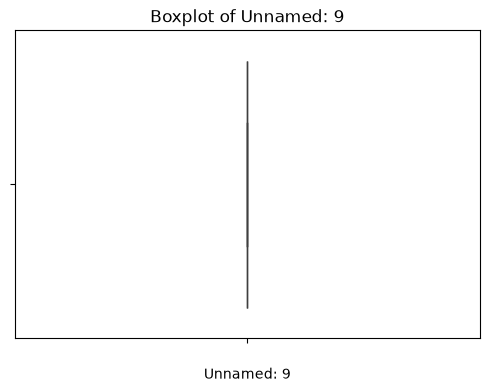

In [18]:
features = df.drop("Class (1, 2, 3)",axis=1).columns

for features in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[features])
    
    plt.title(f"Boxplot of {features}")
    plt.xlabel(features)
    plt.show()
    

In [19]:
plt.figure(figsize=(10,7))

correlation = df.corr()

sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

ValueError: could not convert string to float: ' '

<Figure size 1000x700 with 0 Axes>

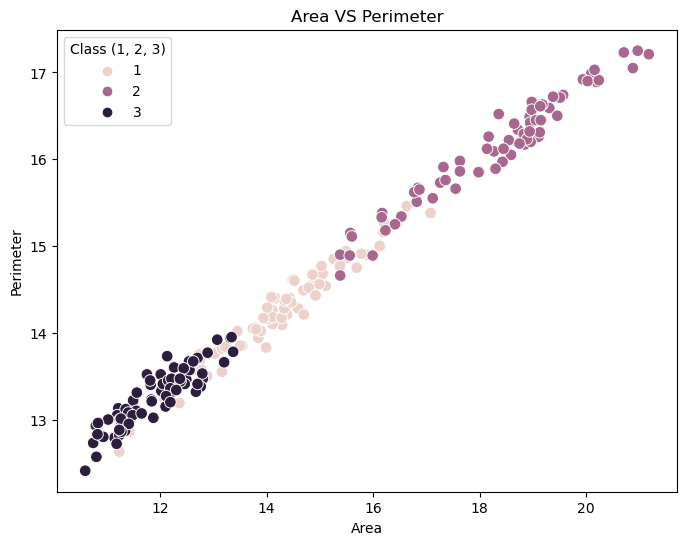

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="Area",y="Perimeter",hue="Class (1, 2, 3)",s=70)

plt.title("Area VS Perimeter")
plt.show()

C:\Users\cse\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


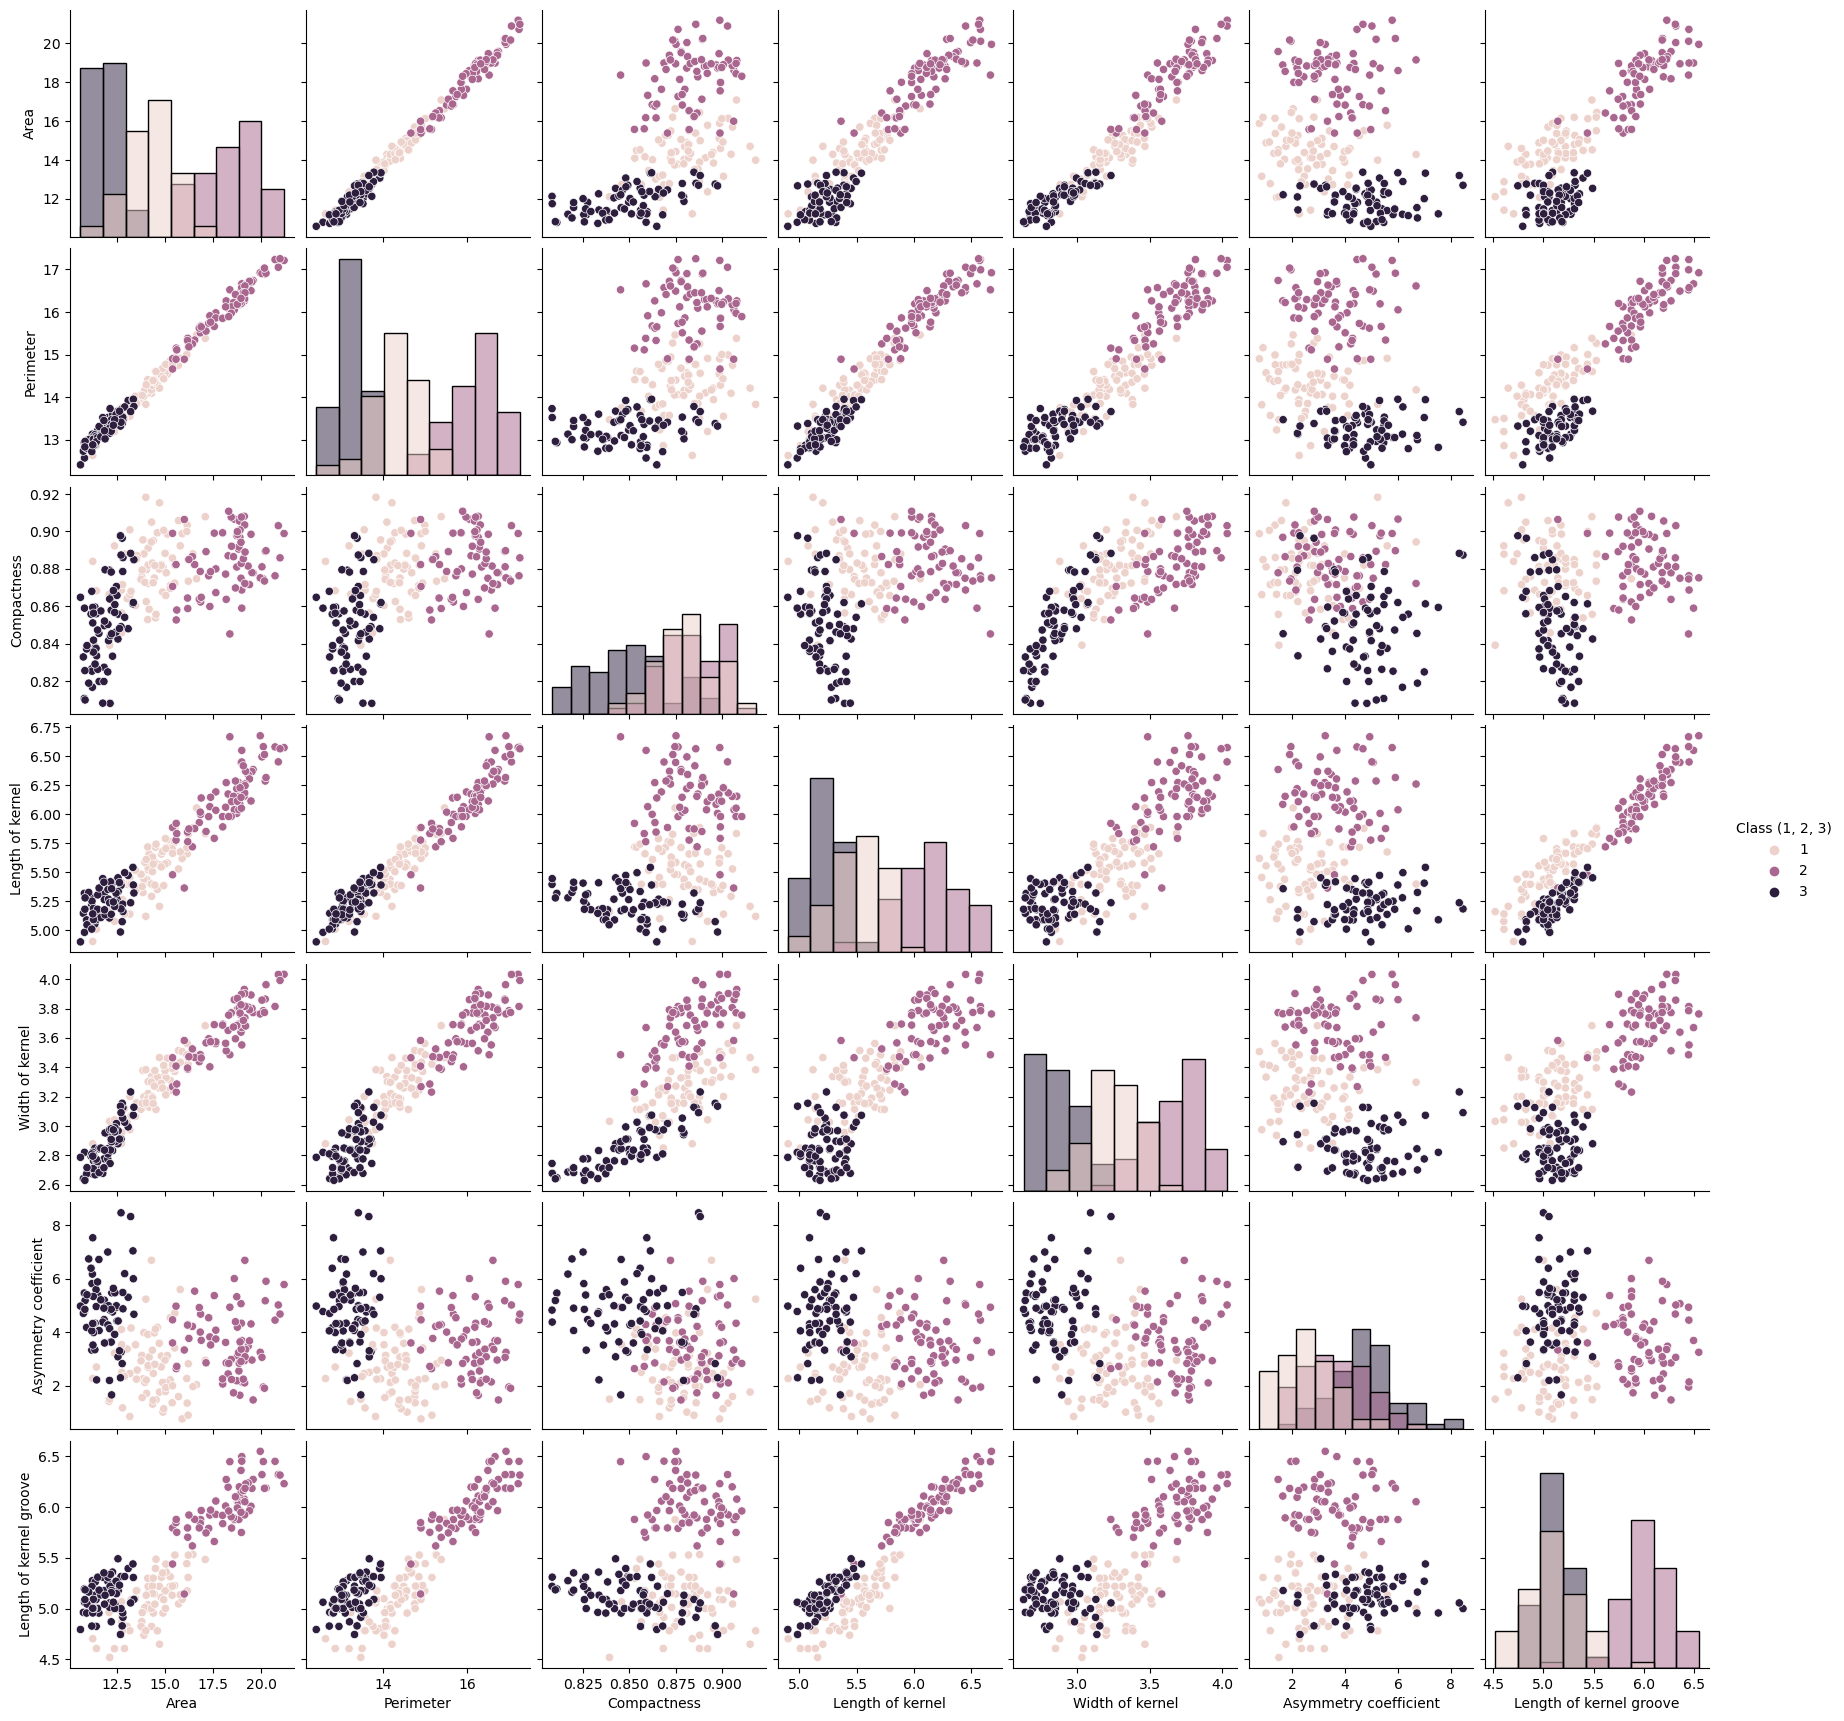

In [ ]:
sns.pairplot(df,hue="Class (1, 2, 3)",diag_kind="hist")
plt.show()

In [ ]:
X= df.drop("Class (1, 2, 3)",axis=1)
y_original=df["Class (1, 2, 3)"]
print("Input shape",X.shape)
print("OTarget shape:",y_original.shape)

Input shape (210, 7)
OTarget shape: (210,)


In [ ]:
y=y_original -1 

print("Original calasses:")
print(sorted(y_original.unique()))

print("\n ANN encoded classes")
print(sorted(y.unique()))

Original calasses:
[1, 2, 3]

 ANN encoded classes
[0, 1, 2]


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 168
Testing samples:  42


In [ ]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [ ]:
print("First 5 sacled training samples")
print(X_train_scaled[:5])

First 5 sacled training samples
[[-1.17682401 -1.1750583  -1.02169157 -1.02785725 -1.35751947  1.43188942
  -0.82441016]
 [-0.87298429 -1.06714618  0.86676795 -1.26492983 -0.59897345 -0.3056117
  -1.63150367]
 [-0.12719589  0.01968295 -0.66917913  0.25096694 -0.40933695 -1.4432301
   0.1615857 ]
 [-1.29421662 -1.37546651 -0.66498255 -1.41310019 -1.26136575  1.7668294
  -0.72886004]
 [-0.58295547 -0.70486981  0.69890488 -0.90020279 -0.09149548  3.02743357
  -0.71462918]]


In [ ]:
model = Sequential([
    Input(shape=(7,)),
    Dense(16,activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation= "softmax")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
loss="sparse_categorical_crossentropy"

In [ ]:
early_stop = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

In [ ]:
history=model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size =16,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4910 - loss: 1.0852 - val_accuracy: 0.5000 - val_loss: 1.0811
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5883 - loss: 0.9920 - val_accuracy: 0.4706 - val_loss: 1.0078
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6105 - loss: 0.9410 - val_accuracy: 0.5294 - val_loss: 0.9448
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7137 - loss: 0.8563 - val_accuracy: 0.5294 - val_loss: 0.8954
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7267 - loss: 0.7863 - val_accuracy: 0.5588 - val_loss: 0.8503
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6497 - loss: 0.7756 - val_accuracy: 0.7353 - val_loss: 0.8099
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7688 - loss: 0.6744 - val_accuracy: 0.7353 - val_loss: 0.7772
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7753 - loss: 0.6772 - val_accuracy: 0.7941 - val_loss: 0.7449

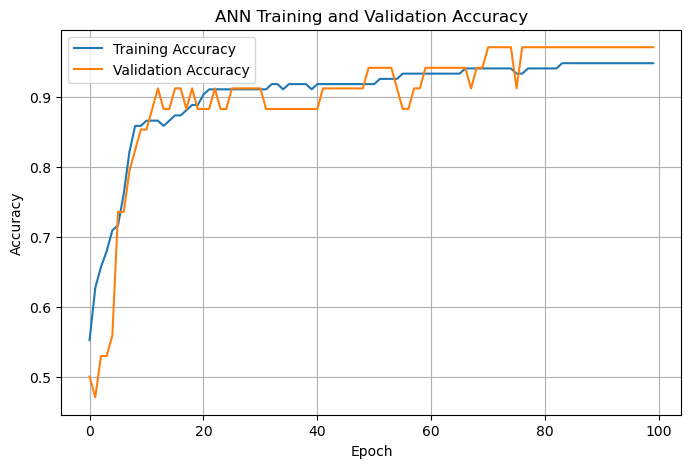

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


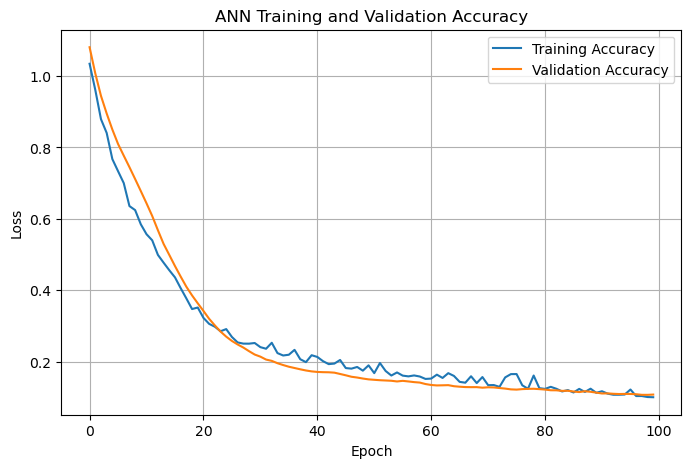

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Accuracy")
plt.plot(history.history["val_loss"], label="Validation Accuracy")

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled,y_test,verbose=1)

print("Test loss:", test_loss)
print("Test Accuracy",test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8527 - loss: 0.4572 
Test loss: 0.4306561350822449
Test Accuracy 0.8571428656578064


In [ ]:
y_prob= model.predict(X_test_scaled,verbose=1)
print(y_prob[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[9.8786783e-01 8.9949858e-04 1.1232689e-02]
 [6.7854151e-02 5.8043092e-03 9.2634153e-01]
 [7.6144809e-01 1.8802245e-01 5.0529413e-02]
 [9.5755449e-03 1.2701635e-04 9.9029750e-01]
 [5.2286667e-04 9.9947494e-01 2.1863266e-06]]


In [ ]:
y_pred = np.argmax(y_prob,axis=1)

print("Predicted encoded classes:")
print(y_pred[:10])

Predicted encoded classes:
[0 2 0 2 1 2 1 1 1 1]


In [ ]:
y_pred_original = y_pred +1
y_test_original = y_test +1

print("Predicted classes:")
print(y_pred_original[:10])

Predicted classes:
[1 3 1 3 2 3 2 2 2 2]


In [ ]:
comparison = pd.DataFrame({"Actual Class": y_test_original.values, "Prediced Class":y_pred_original})
comparison.head()

,Actual Class,Prediced Class
0,1,1
1,3,3
2,2,1
3,3,3
4,2,2


In [ ]:
accuracy = accuracy_score(y_test_original,y_pred_original)
print("Accuracy:",accuracy)

Accuracy: 0.8571428571428571


In [ ]:
precision = precision_score(y_test_original, y_pred_original, average='weighted')
print("Precision (Weighted):", precision)

Precision (Weighted): 0.8625


In [ ]:
recall = recall_score(y_test_original, y_pred_original, average='weighted')
print("Recall:", recall)

Recall: 0.8571428571428571


In [ ]:
f1_score = f1_score(y_test_original, y_pred_original, average='weighted')
print("f1_score:", f1_score)

f1_score: 0.8500000000000001


In [ ]:
report = classification_report(y_test_original, y_pred_original)
print(report)

              precision    recall  f1-score   support

           1       0.90      0.64      0.75        14
           2       0.81      0.93      0.87        14
           3       0.88      1.00      0.93        14

    accuracy                           0.86        42
   macro avg       0.86      0.86      0.85        42
weighted avg       0.86      0.86      0.85        42

